# Capstone 24.1 — Notebook 4: SLA-Breach Classification

**Author:** Sravanthi Gandu

**Modeling task.** A **supervised binary classification** problem that answers the operational
half of the research question directly: *at intake, will this ticket miss its committed due
date?* The positive class (`breached = 1`) is a ticket whose actual resolution ran **past its
own `due_date`**. This turns the regression effort estimate of Notebook 3 into an explicit,
actionable **at-risk flag** operations can act on the moment a ticket arrives.

We compare three classifier families with **5-fold cross-validation**, tune the strongest with
**`GridSearchCV`**, and evaluate on a held-out test set using ROC-AUC, recall, precision, and
the confusion matrix.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, cross_validate,
                                     StratifiedKFold, GridSearchCV)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

## 1. Define the target — did the ticket breach its due date?

`due_date` is set the moment a ticket is created, so the **SLA window** (`due_date -
create_date`, in days) is a legitimate intake-time feature. A ticket **breaches** when its
actual `resolution_days` exceeds that window.

In [2]:
df = pd.read_csv("../data/cpt_clean.csv")

# Resolved tickets with a genuine positive duration
clf_df = df[df["resolution_days"].notna() & (df["resolution_days"] > 0)].copy()

# SLA window known at intake: promised days between creation and due date
clf_df["create_date"] = pd.to_datetime(clf_df["create_date"], errors="coerce", utc=True)
clf_df["due_date"] = pd.to_datetime(clf_df["due_date"], errors="coerce", utc=True)
clf_df["sla_window_days"] = (clf_df["due_date"] - clf_df["create_date"]).dt.total_seconds() / 86400
clf_df = clf_df[clf_df["sla_window_days"].notna()].copy()

# Label: breached SLA = resolved after the committed due date
clf_df["breached"] = (clf_df["resolution_days"] > clf_df["sla_window_days"]).astype(int)

rate = clf_df["breached"].mean()
print(f"Tickets: {len(clf_df):,}")
print(f"Breached (class 1): {clf_df['breached'].sum():,}  ({rate:.1%})")
print(f"On-time  (class 0): {(1 - clf_df['breached']).sum():,}  ({1 - rate:.1%})")

Tickets: 6,615
Breached (class 1): 2,304  (34.8%)
On-time  (class 0): 4,311  (65.2%)


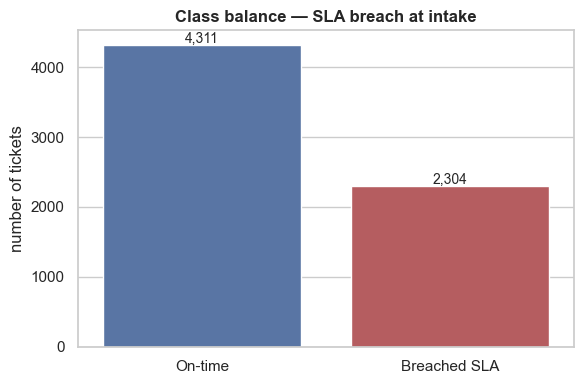

In [3]:
# Visualize the class balance
fig, ax = plt.subplots(figsize=(6, 4))
counts = clf_df["breached"].map({0: "On-time", 1: "Breached SLA"}).value_counts()
sns.barplot(x=counts.index, y=counts.values, hue=counts.index,
            palette=["#4C72B0", "#C44E52"], legend=False, ax=ax)
for i, v in enumerate(counts.values):
    ax.text(i, v + 30, f"{v:,}", ha="center", fontsize=10)
ax.set_title("Class balance — SLA breach at intake", fontsize=12, weight="bold")
ax.set_ylabel("number of tickets")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

## 2. Feature set (intake-time only) & train/test split

Same leak-free intake features as the regression notebook, plus the **SLA window** itself —
a tight promised window is intuitively a strong breach signal. We stratify the split so both
sets keep the same breach rate.

In [4]:
CATEGORICAL = ["order_type", "geo", "market_segment", "offer_family",
               "cloud", "type", "requestor_system"]
NUMERIC = ["sla_window_days", "offer_quantity", "line_items_per_ticket",
           "create_month", "create_week", "create_dow", "create_hour"]

X = clf_df[CATEGORICAL + NUMERIC]
y = clf_df["breached"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {X_train.shape[0]:,} rows ({y_train.mean():.1%} breached) | "
      f"Test: {X_test.shape[0]:,} rows ({y_test.mean():.1%} breached)")

Train: 5,292 rows (34.8% breached) | Test: 1,323 rows (34.8% breached)


## 3. Preprocessing pipeline

One-hot encode categoricals (rare levels collapsed), median-impute + standardize numerics.
Fit inside each CV fold so no test information leaks.

In [5]:
categorical_tf = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value="UNKNOWN")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=50)),
])
numeric_tf = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])
preprocess = ColumnTransformer([
    ("cat", categorical_tf, CATEGORICAL),
    ("num", numeric_tf, NUMERIC),
])

def make_pipe(model):
    return Pipeline([("prep", preprocess), ("model", model)])

## 4. Model comparison with 5-fold cross-validation

We benchmark Logistic Regression, Random Forest, and Gradient Boosting. The headline score is
**ROC-AUC** (threshold-free ranking quality); we also track **recall** on the breach class,
because in operations the costly mistake is *missing* a ticket that will breach.

In [6]:
scoring = {"ROC_AUC": "roc_auc", "Recall": "recall",
           "Precision": "precision", "F1": "f1"}

candidates = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced",
                                              random_state=RANDOM_STATE),
    "Random Forest":       RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                                  class_weight="balanced",
                                                  random_state=RANDOM_STATE),
    "Gradient Boosting":   GradientBoostingClassifier(random_state=RANDOM_STATE),
}

rows = []
for name, est in candidates.items():
    cvres = cross_validate(make_pipe(est), X_train, y_train, cv=CV,
                           scoring=scoring, n_jobs=-1)
    rows.append({
        "Model": name,
        "CV ROC-AUC": cvres["test_ROC_AUC"].mean(),
        "AUC std": cvres["test_ROC_AUC"].std(),
        "CV Recall": cvres["test_Recall"].mean(),
        "CV Precision": cvres["test_Precision"].mean(),
        "CV F1": cvres["test_F1"].mean(),
    })

cv_results = pd.DataFrame(rows).sort_values("CV ROC-AUC", ascending=False).reset_index(drop=True)
cv_results.round(3)

,Model,CV ROC-AUC,AUC std,CV Recall,CV Precision,CV F1
0,Random Forest,0.884,0.014,0.727,0.796,0.760
1,Gradient Boosting,0.880,0.011,0.621,0.839,0.713
2,Logistic Regression,0.832,0.016,0.751,0.652,0.698


## 5. Hyperparameter tuning with `GridSearchCV`

The best family (Gradient Boosting) is tuned on ROC-AUC over the same 5-fold split.

In [7]:
gb_pipe = make_pipe(GradientBoostingClassifier(random_state=RANDOM_STATE))
gb_grid = {
    "model__n_estimators": [200, 400],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3],
    "model__subsample": [0.8, 1.0],
}
gb_search = GridSearchCV(gb_pipe, gb_grid, scoring="roc_auc", cv=CV, n_jobs=-1)
gb_search.fit(X_train, y_train)
print("Gradient Boosting")
print("  best params:", {k.replace('model__', ''): v
                          for k, v in gb_search.best_params_.items()})
print(f"  best CV ROC-AUC: {gb_search.best_score_:.3f}")

Gradient Boosting
  best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 400, 'subsample': 0.8}
  best CV ROC-AUC: 0.892


## 6. Final evaluation on the held-out test set

In [8]:
best_clf = gb_search.best_estimator_
proba = best_clf.predict_proba(X_test)[:, 1]
pred = best_clf.predict(X_test)

print(f"Test ROC-AUC: {roc_auc_score(y_test, proba):.3f}")
print(f"Test PR-AUC : {average_precision_score(y_test, proba):.3f}")
print()
print(classification_report(y_test, pred, target_names=["On-time", "Breached"]))

Test ROC-AUC: 0.896
Test PR-AUC : 0.851

              precision    recall  f1-score   support

     On-time       0.83      0.90      0.87       862
    Breached       0.78      0.66      0.72       461

    accuracy                           0.82      1323
   macro avg       0.81      0.78      0.79      1323
weighted avg       0.82      0.82      0.81      1323



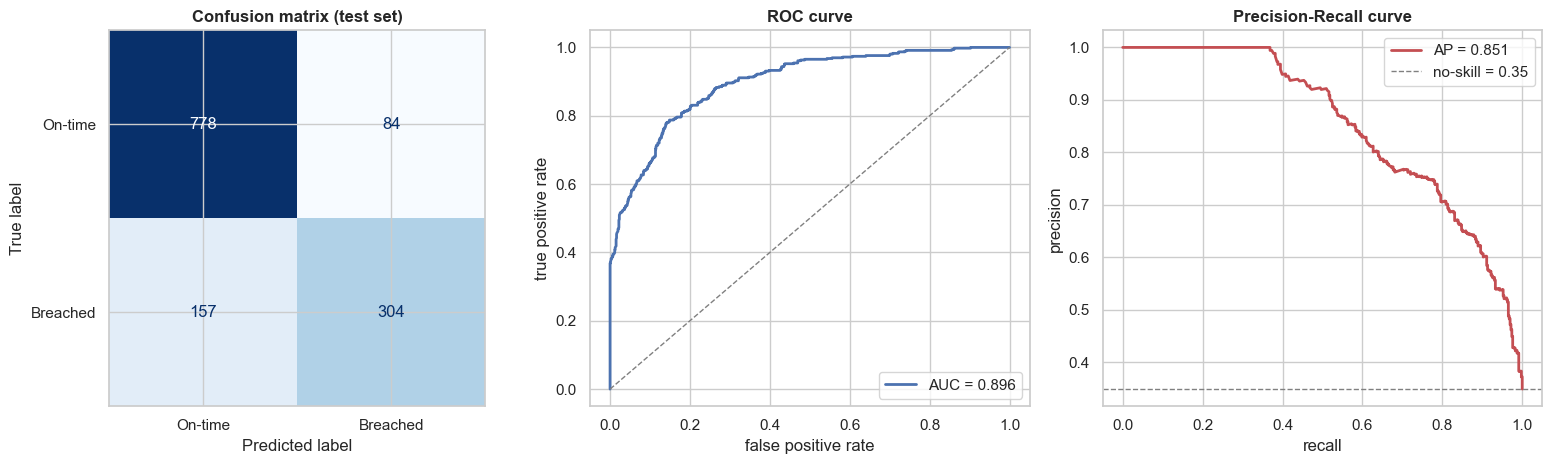

In [9]:
# Confusion matrix, ROC curve, precision-recall curve
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

cm = confusion_matrix(y_test, pred)
ConfusionMatrixDisplay(cm, display_labels=["On-time", "Breached"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Confusion matrix (test set)", fontsize=12, weight="bold")

fpr, tpr, _ = roc_curve(y_test, proba)
axes[1].plot(fpr, tpr, color="#4C72B0", lw=2,
             label=f"AUC = {roc_auc_score(y_test, proba):.3f}")
axes[1].plot([0, 1], [0, 1], "--", color="grey", lw=1)
axes[1].set_title("ROC curve", fontsize=12, weight="bold")
axes[1].set_xlabel("false positive rate")
axes[1].set_ylabel("true positive rate")
axes[1].legend(loc="lower right")

prec, rec, _ = precision_recall_curve(y_test, proba)
axes[2].plot(rec, prec, color="#C44E52", lw=2,
             label=f"AP = {average_precision_score(y_test, proba):.3f}")
axes[2].axhline(y_test.mean(), ls="--", color="grey", lw=1,
                label=f"no-skill = {y_test.mean():.2f}")
axes[2].set_title("Precision-Recall curve", fontsize=12, weight="bold")
axes[2].set_xlabel("recall")
axes[2].set_ylabel("precision")
axes[2].legend(loc="upper right")

plt.tight_layout()
plt.show()

## 7. What signals an at-risk ticket? (feature importances)

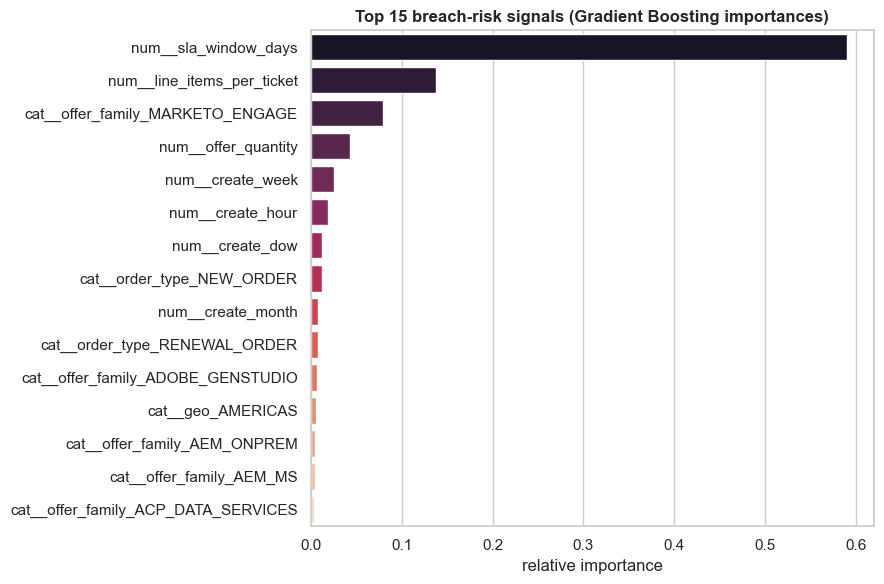

In [10]:
feat_names = best_clf.named_steps["prep"].get_feature_names_out()
importances = pd.Series(best_clf.named_steps["model"].feature_importances_,
                        index=feat_names).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index,
            palette="rocket", legend=False, ax=ax)
ax.set_title("Top 15 breach-risk signals (Gradient Boosting importances)",
             fontsize=12, weight="bold")
ax.set_xlabel("relative importance")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 8. Interpretation & choice of evaluation metric

**Result.** All three families beat the ~35%% no-skill rate comfortably. In cross-validation the
tree ensembles lead (**Random Forest ROC-AUC 0.88, Gradient Boosting 0.88**) over Logistic
Regression (0.83). After `GridSearchCV` tuning, the **Gradient Boosting** classifier reaches
**ROC-AUC 0.896** and **PR-AUC 0.851** on the held-out test set (n = 1,323), correctly flagging
**66%% of tickets that actually breach (recall)** at **78%% precision** — i.e. nearly 4 of every 5
flagged tickets really do breach. The feature-importance chart (Section 7) shows the **SLA
window itself** and a handful of offer families / segments carry most of the signal: tight
promised windows on certain product lines are the clearest at-risk markers.

**Why these metrics.** SLA-breach detection is an **imbalanced, cost-asymmetric** problem, so
plain accuracy is misleading (always predicting "on-time" would already score ~65%%). We judge
models on:

* **ROC-AUC** - threshold-free ranking quality; the primary model-selection metric because it
  is insensitive to where we set the alert cutoff.
* **Recall on the breach class** - of all tickets that truly breach, how many did we flag? In
  operations a missed at-risk ticket (false negative) is the expensive error, so recall is
  watched closely.
* **Precision** - of the tickets we flag, how many really breach? This governs alert fatigue.
* **PR-AUC / F1** - summarize the precision-recall trade-off on the minority (breach) class.

The operating threshold can be slid along the PR curve (Section 6) to match the team's
tolerance for false alarms versus missed breaches - e.g. lowering it raises recall for
periods when catching every at-risk ticket matters more than a few extra alerts.

**Next steps.** Wire the breach probability into the intake queue as a live risk score, tune
the alert threshold with operations, and combine it with the Notebook 3 effort estimate so
each incoming ticket carries both a *predicted duration* and a *breach-risk flag*.